# Model Experiment — LightGBM



## Section 1 — Imports & Setup
Loads libraries, mounts Drive, sets random seeds for reproducibility.

In [25]:
# !pip install lightgbm -q   # uncomment if Colab doesn't already have it

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import wandb
import lightgbm as lgb
from sklearn.feature_selection import mutual_info_regression, f_regression
from sklearn.ensemble import RandomForestRegressor

from google.colab import drive
drive.mount('/content/drive')

pd.set_option('display.max_columns', 100)
np.random.seed(42)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Section 2 — Load Cleaned Data
Reads the shared cleaned dataset produced by `Data_Overview.ipynb`.

In [26]:
path = '/content/drive/MyDrive/ML-final/data/processed/'

df = pd.read_csv(path + 'walmart_cleaned.csv')
df['Date'] = pd.to_datetime(df['Date'])

markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']

print("Loaded cleaned data:", df.shape)
print(df.isnull().sum().sum(), "missing values remaining")

Loaded cleaned data: (421570, 16)
0 missing values remaining


## Section 3 — Wandb Login
Authenticates this session for experiment logging.

In [27]:
wandb.login()

True

## Section 4 — Confirm Clean Data (`LightGBM_Cleaning`)


In [28]:
run = wandb.init(project="walmart-sales-forecasting", group="LightGBM_Training",
                  name="LightGBM_Cleaning", job_type="preprocessing")

wandb.log({
    "rows": df.shape[0],
    "cols": df.shape[1],
    "missing_values_total": int(df.isnull().sum().sum()),
})
wandb.config.update({"source_file": "walmart_cleaned.csv (produced by Data_Overview.ipynb)"})

wandb.finish()
print("LightGBM_Cleaning run finished")

cols,▁
missing_values_total,▁
rows,▁
cols,16
missing_values_total,0
rows,421570


LightGBM_Cleaning run finished


## Section 5 — Feature Engineering (`LightGBM_Feature_Engineering`)


In [29]:
run = wandb.init(project="walmart-sales-forecasting", group="LightGBM_Training",
                  name="LightGBM_Feature_Engineering", job_type="feature-engineering")

# --- Calendar features ---
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week.astype(int)
df['Day'] = df['Date'].dt.day

# --- Numeric encodings ---
type_mapping = {'A': 3, 'B': 2, 'C': 1}
df['Type'] = df['Type'].map(type_mapping)
df['IsHoliday'] = df['IsHoliday'].astype(int)

# --- Markdown aggregate features ---
df['Total_Markdown'] = df[markdown_cols].sum(axis=1)
df['Has_Markdown'] = (df['Total_Markdown'] > 0).astype(int)
df['Markdown_Count'] = (df[markdown_cols] > 0).sum(axis=1)

# --- Holiday-proximity flags ---
holiday_dates = {
    'Is_SuperBowl':    pd.to_datetime(['2010-02-12', '2011-02-11', '2012-02-10', '2013-02-08']),
    'Is_LaborDay':     pd.to_datetime(['2010-09-10', '2011-09-09', '2012-09-07', '2013-09-06']),
    'Is_Thanksgiving': pd.to_datetime(['2010-11-26', '2011-11-25', '2012-11-23', '2013-11-29']),
    'Is_Christmas':    pd.to_datetime(['2010-12-31', '2011-12-30', '2012-12-28', '2013-12-27']),
}
for col, dates in holiday_dates.items():
    df[col] = df['Date'].isin(dates).astype(int)

# --- Days to/since nearest holiday (continuous signal, not just binary) ---
all_holiday_dates = pd.to_datetime(sorted(set(d for dates in holiday_dates.values() for d in dates)))

def days_to_next_holiday(date):
    future = all_holiday_dates[all_holiday_dates > date]
    return (future.min() - date).days if len(future) else np.nan

def days_since_last_holiday(date):
    past = all_holiday_dates[all_holiday_dates < date]
    return (date - past.max()).days if len(past) else np.nan

df['Days_To_Next_Holiday'] = df['Date'].apply(days_to_next_holiday)
df['Days_Since_Last_Holiday'] = df['Date'].apply(days_since_last_holiday)

print("Calendar + markdown + holiday features added.")

# --- Lag & rolling features (per Store-Dept time series) ---
df = df.sort_values(['Store', 'Dept', 'Date']).reset_index(drop=True)
grp = df.groupby(['Store', 'Dept'])['Weekly_Sales']

df['Sales_Lag1']      = grp.shift(1)
df['Sales_Lag2']      = grp.shift(2)
df['Sales_Lag3']      = grp.shift(3)
df['Sales_Lag52']     = grp.shift(52)
df['Sales_RollMean4'] = grp.transform(lambda s: s.shift(1).rolling(4).mean())
df['Sales_RollStd4']  = grp.transform(lambda s: s.shift(1).rolling(4).std())

lag_na = df[['Sales_Lag1', 'Sales_Lag2', 'Sales_Lag3', 'Sales_Lag52',
             'Sales_RollMean4', 'Sales_RollStd4']].isna().sum()
print("NA in lag/rolling features (expected at each series' start; LightGBM handles NaN natively too):")
print(lag_na)

Calendar + markdown + holiday features added.
NA in lag/rolling features (expected at each series' start; LightGBM handles NaN natively too):
Sales_Lag1           3331
Sales_Lag2           6625
Sales_Lag3           9889
Sales_Lag52        160487
Sales_RollMean4     13134
Sales_RollStd4      13134
dtype: int64


In [30]:
def compute_best_partner(data):
    pivot = data.pivot_table(index='Date', columns='Dept', values='Weekly_Sales', aggfunc='mean')
    corr = pivot.corr().to_numpy().copy()
    dept_ids = pivot.columns.to_numpy()
    np.fill_diagonal(corr, -np.inf)  # exclude self-correlation from being picked as the partner
    return {dept_ids[i]: dept_ids[np.argmax(corr[i])] for i in range(len(dept_ids))}

def compute_avg_maps(data):
    dept_avg = data.groupby('Dept')['Weekly_Sales'].mean().to_dict()
    store_avg = data.groupby('Store')['Weekly_Sales'].mean().to_dict()
    overall_avg = data['Weekly_Sales'].mean()
    return dept_avg, store_avg, overall_avg

best_partner = compute_best_partner(df)
df['Partner_Dept'] = df['Dept'].map(best_partner)

lag1_lookup = df[['Store', 'Dept', 'Date', 'Sales_Lag1']].rename(
    columns={'Dept': 'Partner_Dept', 'Sales_Lag1': 'Partner_Dept_Sales_Lag1'})
df = pd.merge(df, lag1_lookup, on=['Store', 'Partner_Dept', 'Date'], how='left')

dept_avg_map, store_avg_map, overall_mean_sales = compute_avg_maps(df)
df['Dept_Avg_Sales']  = df['Dept'].map(dept_avg_map)
df['Store_Avg_Sales'] = df['Store'].map(store_avg_map)

print("Partner_Dept_Sales_Lag1 NA:", df['Partner_Dept_Sales_Lag1'].isna().sum(), "/", len(df))

wandb.log({
    "na_Sales_Lag1": int(lag_na['Sales_Lag1']),
    "na_Sales_Lag52": int(lag_na['Sales_Lag52']),
    "na_Partner_Dept_Sales_Lag1": int(df['Partner_Dept_Sales_Lag1'].isna().sum()),
})
wandb.config.update({
    "lag_feature_na_strategy": "left_as_NaN_lightgbm_native_handling",
    "cross_dept_feature_source": "best_positive_correlation_partner_dept_lag1",
    "leakage_note": "avg/partner maps fit on full df for now; must refit per-fold once CV is added",
})

# Save lookup maps as a wandb artifact
os.makedirs('/content/lookup_maps_lgbm', exist_ok=True)
with open('/content/lookup_maps_lgbm/dept_avg_map.json', 'w') as f:
    json.dump({str(k): v for k, v in dept_avg_map.items()}, f)
with open('/content/lookup_maps_lgbm/store_avg_map.json', 'w') as f:
    json.dump({str(k): v for k, v in store_avg_map.items()}, f)
with open('/content/lookup_maps_lgbm/best_partner_map.json', 'w') as f:
    json.dump({str(k): int(v) for k, v in best_partner.items()}, f)
with open('/content/lookup_maps_lgbm/overall_mean_sales.json', 'w') as f:
    json.dump({"overall_mean_sales": overall_mean_sales}, f)

lookup_artifact = wandb.Artifact(name="train_only_lookup_tables_lightgbm", type="preprocessing-maps",
                                  description="Dept/Store avg sales + best-partner-dept map (LightGBM notebook)")
for fname in ["dept_avg_map.json", "store_avg_map.json", "best_partner_map.json", "overall_mean_sales.json"]:
    lookup_artifact.add_file(f"/content/lookup_maps_lgbm/{fname}")
wandb.run.log_artifact(lookup_artifact)

wandb.finish()
print("LightGBM_Feature_Engineering run finished")

Partner_Dept_Sales_Lag1 NA: 26496 / 421570


wandb: WARNING Artifact "train_only_lookup_tables_lightgbm" already exists with the same content. No new version will be created.


na_Partner_Dept_Sales_Lag1,▁
na_Sales_Lag1,▁
na_Sales_Lag52,▁
na_Partner_Dept_Sales_Lag1,26496
na_Sales_Lag1,3331
na_Sales_Lag52,160487


LightGBM_Feature_Engineering run finished


## Section 6 — Feature Selection (`LightGBM_Feature_Selection`)


Top 15 selected features: ['Sales_Lag1', 'Sales_Lag52', 'Sales_RollMean4', 'Sales_Lag3', 'Sales_Lag2', 'Sales_RollStd4', 'Dept_Avg_Sales', 'Partner_Dept_Sales_Lag1', 'Store_Avg_Sales', 'Size', 'MarkDown5', 'Unemployment', 'Total_Markdown', 'MarkDown3', 'MarkDown1']


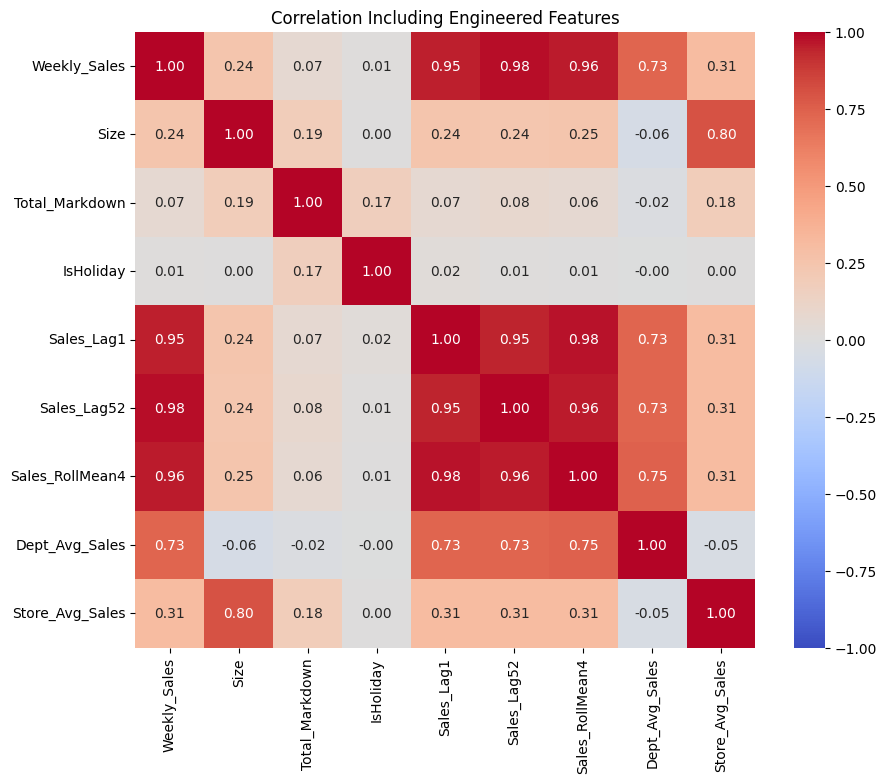

LightGBM_Feature_Selection run finished


In [31]:
run = wandb.init(project="walmart-sales-forecasting", group="LightGBM_Training",
                  name="LightGBM_Feature_Selection", job_type="feature-selection")

exclude_cols = ['Weekly_Sales', 'Date', 'Store', 'Dept', 'Partner_Dept']
candidate_features = [c for c in df.columns if c not in exclude_cols and df[c].dtype != 'object']

fs_df = df[candidate_features + ['Weekly_Sales']].dropna()
fs_sample = fs_df.sample(n=min(50000, len(fs_df)), random_state=42)
X = fs_sample[candidate_features]
y = fs_sample['Weekly_Sales']

f_scores, _ = f_regression(X, y)
mi_scores = mutual_info_regression(X, y, random_state=42)

rf = RandomForestRegressor(n_estimators=100, max_depth=8, n_jobs=-1, random_state=42)
rf.fit(X, y)

selection_df = pd.DataFrame({
    'F_test_rank': pd.Series(f_scores, index=candidate_features).rank(ascending=False),
    'MI_rank': pd.Series(mi_scores, index=candidate_features).rank(ascending=False),
    'RF_rank': pd.Series(rf.feature_importances_, index=candidate_features).rank(ascending=False),
})
selection_df['avg_rank'] = selection_df.mean(axis=1)
selection_df = selection_df.sort_values('avg_rank')

wandb.log({"Feature_Selection_Scores": wandb.Table(
    dataframe=selection_df.reset_index().rename(columns={'index': 'feature'}))})

selected_features = selection_df.head(15).index.tolist()
print("Top 15 selected features:", selected_features)
wandb.config.update({"selected_features": selected_features})

corr_cols = ['Weekly_Sales', 'Size', 'Total_Markdown', 'IsHoliday',
             'Sales_Lag1', 'Sales_Lag52', 'Sales_RollMean4',
             'Dept_Avg_Sales', 'Store_Avg_Sales']
plt.figure(figsize=(10, 8))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Including Engineered Features")
wandb.log({"Engineered_Feature_Correlations": wandb.Image(plt)})
plt.show()
plt.close()

wandb.finish()
print("LightGBM_Feature_Selection run finished")

## Section 7 — Save Engineered Dataset


In [32]:
out_dir = '/content/drive/MyDrive/ML-final/data/processed/'
os.makedirs(out_dir, exist_ok=True)
out_path = out_dir + 'walmart_engineered_lightgbm.csv'
df.to_csv(out_path, index=False)

run = wandb.init(project="walmart-sales-forecasting", group="LightGBM_Training",
                  name="LightGBM_Save_Engineered_Data", job_type="dataset-export")

artifact = wandb.Artifact(name="engineered_walmart_data_lightgbm", type="dataset",
                           description="Cleaned + LightGBM-specific engineered features")
artifact.add_file(out_path)
wandb.run.log_artifact(artifact)
wandb.config.update({"n_rows": df.shape[0], "n_cols": df.shape[1]})

wandb.finish()
print(f"Saved engineered data: {df.shape} -> {out_path}")

wandb: WARNING Artifact "engineered_walmart_data_lightgbm" already exists with the same content. No new version will be created.


Saved engineered data: (421570, 39) -> /content/drive/MyDrive/ML-final/data/processed/walmart_engineered_lightgbm.csv


## Section 8 — Preprocessing Pipeline (for inference)


In [33]:
class LightGBMPreprocessingPipeline:
    """Wraps cleaning + feature engineering so the exact same transform can be
    applied to test.csv at inference time. Lookup maps (dept/store averages,
    best partner dept) are fit once on training data and passed in here --
    they must NOT be recomputed on test data."""

    def __init__(self, dept_avg_map, store_avg_map, best_partner, overall_mean_sales,
                 markdown_cols, train_history):
        self.dept_avg_map = dept_avg_map
        self.store_avg_map = store_avg_map
        self.best_partner = best_partner
        self.overall_mean_sales = overall_mean_sales
        self.markdown_cols = markdown_cols
        self.train_history = train_history[['Store', 'Dept', 'Date', 'Weekly_Sales']].copy()

        self.holiday_dates = {
            'Is_SuperBowl':    pd.to_datetime(['2010-02-12', '2011-02-11', '2012-02-10', '2013-02-08']),
            'Is_LaborDay':     pd.to_datetime(['2010-09-10', '2011-09-09', '2012-09-07', '2013-09-06']),
            'Is_Thanksgiving': pd.to_datetime(['2010-11-26', '2011-11-25', '2012-11-23', '2013-11-29']),
            'Is_Christmas':    pd.to_datetime(['2010-12-31', '2011-12-30', '2012-12-28', '2013-12-27']),
        }
        self.all_holiday_dates = pd.to_datetime(
            sorted(set(d for dates in self.holiday_dates.values() for d in dates)))

    def _days_to_next_holiday(self, date):
        future = self.all_holiday_dates[self.all_holiday_dates > date]
        return (future.min() - date).days if len(future) else np.nan

    def _days_since_last_holiday(self, date):
        past = self.all_holiday_dates[self.all_holiday_dates < date]
        return (date - past.max()).days if len(past) else np.nan

    def transform(self, raw_df, stores_df, features_df):
        """raw_df: same columns as train.csv/test.csv (Weekly_Sales optional)."""
        data = pd.merge(raw_df, stores_df, on='Store', how='left')
        data = pd.merge(data, features_df, on=['Store', 'Date', 'IsHoliday'], how='left')
        data['Date'] = pd.to_datetime(data['Date'])
        has_target = 'Weekly_Sales' in data.columns

        # missing values
        data[self.markdown_cols] = data[self.markdown_cols].fillna(0)
        data = data.sort_values(['Store', 'Date']).reset_index(drop=True)
        data['CPI'] = data.groupby('Store')['CPI'].transform(lambda s: s.ffill().bfill())
        data['Unemployment'] = data.groupby('Store')['Unemployment'].transform(lambda s: s.ffill().bfill())

        # calendar + encodings
        data['Year'] = data['Date'].dt.year
        data['Month'] = data['Date'].dt.month
        data['Week'] = data['Date'].dt.isocalendar().week.astype(int)
        data['Day'] = data['Date'].dt.day
        data['Type'] = data['Type'].map({'A': 3, 'B': 2, 'C': 1})
        data['IsHoliday'] = data['IsHoliday'].astype(int)

        # markdown-based
        data['Total_Markdown'] = data[self.markdown_cols].sum(axis=1)
        data['Has_Markdown'] = (data['Total_Markdown'] > 0).astype(int)
        data['Markdown_Count'] = (data[self.markdown_cols] > 0).sum(axis=1)

        # holiday proximity (binary + continuous distance)
        for col, dates in self.holiday_dates.items():
            data[col] = data['Date'].isin(dates).astype(int)
        data['Days_To_Next_Holiday'] = data['Date'].apply(self._days_to_next_holiday)
        data['Days_Since_Last_Holiday'] = data['Date'].apply(self._days_since_last_holiday)

        # lag/rolling: glue stored train history in front so future (test) rows
        # get correct lag values, then split back apart afterward
        incoming_ids = data[['Store', 'Dept', 'Date']].copy()
        if not has_target:
            data['Weekly_Sales'] = np.nan
        combined = pd.concat([self.train_history, data], ignore_index=True, sort=False)
        combined = combined.sort_values(['Store', 'Dept', 'Date']).reset_index(drop=True)
        grp = combined.groupby(['Store', 'Dept'])['Weekly_Sales']
        combined['Sales_Lag1']      = grp.shift(1)
        combined['Sales_Lag2']      = grp.shift(2)
        combined['Sales_Lag3']      = grp.shift(3)
        combined['Sales_Lag52']     = grp.shift(52)
        combined['Sales_RollMean4'] = grp.transform(lambda s: s.shift(1).rolling(4).mean())
        combined['Sales_RollStd4']  = grp.transform(lambda s: s.shift(1).rolling(4).std())

        # cross-department partner lag
        combined['Partner_Dept'] = combined['Dept'].map(self.best_partner)
        lag1_lookup = combined[['Store', 'Dept', 'Date', 'Sales_Lag1']].rename(
            columns={'Dept': 'Partner_Dept', 'Sales_Lag1': 'Partner_Dept_Sales_Lag1'})
        combined = pd.merge(combined, lag1_lookup, on=['Store', 'Partner_Dept', 'Date'], how='left')

        result = pd.merge(incoming_ids, combined, on=['Store', 'Dept', 'Date'], how='left')
        if not has_target:
            result = result.drop(columns=['Weekly_Sales'])

        # dept/store averages: train-only maps, fallback for unseen ids
        result['Dept_Avg_Sales']  = result['Dept'].map(self.dept_avg_map).fillna(self.overall_mean_sales)
        result['Store_Avg_Sales'] = result['Store'].map(self.store_avg_map).fillna(self.overall_mean_sales)

        return result


preprocessing_pipeline = LightGBMPreprocessingPipeline(
    dept_avg_map=dept_avg_map,
    store_avg_map=store_avg_map,
    best_partner=best_partner,
    overall_mean_sales=overall_mean_sales,
    markdown_cols=markdown_cols,
    train_history=df,
)

print("Preprocessing pipeline built. Usage: preprocessing_pipeline.transform(raw_df, stores, features)")

Preprocessing pipeline built. Usage: preprocessing_pipeline.transform(raw_df, stores, features)


## Section 9 — Time-Based Train/Validation Split
Holding out a stretch of real weeks as validation, mimicking how the model will actually be used. Cutoff picked deliberately at Oct 1, 2011 (not just "last N weeks") so validation spans a full year and catches all 4 holidays, including 2011's Thanksgiving/Christmas -- the highest-stakes weeks in the competition.

In [34]:
cutoff_date = pd.Timestamp('2011-10-01')

train_data = df[df['Date'] <= cutoff_date].copy()
val_data = df[df['Date'] > cutoff_date].copy()

print(f"Train: {train_data.shape[0]} rows, {train_data['Date'].min().date()} to {train_data['Date'].max().date()}")
print(f"Val:   {val_data.shape[0]} rows, {val_data['Date'].min().date()} to {val_data['Date'].max().date()}")

val_holidays = val_data.loc[val_data['IsHoliday'] == 1, 'Date'].unique()
print(f"\nHoliday weeks inside validation: {len(val_holidays)}")
print(sorted(val_holidays))

Train: 255364 rows, 2010-02-05 to 2011-09-30
Val:   166206 rows, 2011-10-07 to 2012-10-26

Holiday weeks inside validation: 4
[Timestamp('2011-11-25 00:00:00'), Timestamp('2011-12-30 00:00:00'), Timestamp('2012-02-10 00:00:00'), Timestamp('2012-09-07 00:00:00')]


## Section 10 — Recompute Leakage-Prone Features (Train-Only)
`Dept_Avg_Sales`, `Store_Avg_Sales`, and `best_partner` were computed on the *entire* dataset in Section 5, including validation weeks -- refitting them here on `train_data` only prevents a dishonestly optimistic validation score. `Sales_Lag1`/etc. do NOT need refitting -- those only ever look backward within their own series, so they're point-in-time safe regardless of where the cutoff falls.

In [35]:
best_partner_val = compute_best_partner(train_data)
dept_avg_map_val, store_avg_map_val, overall_mean_sales_val = compute_avg_maps(train_data)

def apply_leak_safe_features(data, best_partner_map, dept_map, store_map, overall_avg):
    data = data.copy()
    data['Partner_Dept'] = data['Dept'].map(best_partner_map)

    # Sales_Lag1 itself is already point-in-time safe (see note above), so it's fine to
    # source it from the full df -- only which department counts as the "partner" changes.
    lag1_lookup = df[['Store', 'Dept', 'Date', 'Sales_Lag1']].rename(
        columns={'Dept': 'Partner_Dept', 'Sales_Lag1': 'Partner_Dept_Sales_Lag1'})
    data = data.drop(columns=['Partner_Dept_Sales_Lag1'], errors='ignore')
    data = pd.merge(data, lag1_lookup, on=['Store', 'Partner_Dept', 'Date'], how='left')

    data['Dept_Avg_Sales'] = data['Dept'].map(dept_map).fillna(overall_avg)
    data['Store_Avg_Sales'] = data['Store'].map(store_map).fillna(overall_avg)
    return data

train_data = apply_leak_safe_features(train_data, best_partner_val, dept_avg_map_val,
                                        store_avg_map_val, overall_mean_sales_val)
val_data = apply_leak_safe_features(val_data, best_partner_val, dept_avg_map_val,
                                      store_avg_map_val, overall_mean_sales_val)

print("Train Partner_Dept_Sales_Lag1 NA:", train_data['Partner_Dept_Sales_Lag1'].isna().sum(), "/", len(train_data))
print("Val   Partner_Dept_Sales_Lag1 NA:", val_data['Partner_Dept_Sales_Lag1'].isna().sum(), "/", len(val_data))

Train Partner_Dept_Sales_Lag1 NA: 47982 / 255364
Val   Partner_Dept_Sales_Lag1 NA: 28912 / 166206


## Section 11 — Train LightGBM (`LightGBM_Training`)


In [45]:
def wmae(y_true, y_pred, is_holiday):
    weights = np.where(is_holiday, 5, 1)
    return np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights)

run = wandb.init(project="walmart-sales-forecasting", group="LightGBM_Training",
                  name="LightGBM_Training", job_type="training")

X_train, y_train = train_data[selected_features], train_data['Weekly_Sales']
X_val, y_val = val_data[selected_features], val_data['Weekly_Sales']

model = lgb.LGBMRegressor(num_leaves=127, learning_rate=0.1, n_estimators=1500,
                           subsample=1.0, colsample_bytree=1.0, min_child_samples=50,
                           reg_alpha=1.0, reg_lambda=2.0, random_state=42, n_jobs=-1)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric='l1',
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)],
)

y_pred = model.predict(X_val)
y_pred_clipped = np.clip(y_pred, a_min=0, a_max=None)  # negative sales aren't valid predictions

val_wmae = wmae(y_val.values, y_pred_clipped, val_data['IsHoliday'].values)
val_mae = np.mean(np.abs(y_val.values - y_pred_clipped))

print(f"Best iteration (early stopping): {model.best_iteration_}")
print(f"Validation WMAE: {val_wmae:.2f}")
print(f"Validation MAE:  {val_mae:.2f}")

wandb.config.update({
    "n_estimators": 1000,
    "learning_rate": 0.05,
    "num_leaves": 63,
    "best_iteration": int(model.best_iteration_),
    "features_used": selected_features,
    "validation_cutoff": str(cutoff_date.date()),
})
wandb.log({"val_wmae": val_wmae, "val_mae": val_mae})

wandb.finish()
print("LightGBM_Training run finished")

Best iteration (early stopping): 87
Validation WMAE: 2050.76
Validation MAE:  1647.80


val_mae,▁
val_wmae,▁
val_mae,1647.8039
val_wmae,2050.75947


LightGBM_Training run finished


## Section 12 — Feature Importance


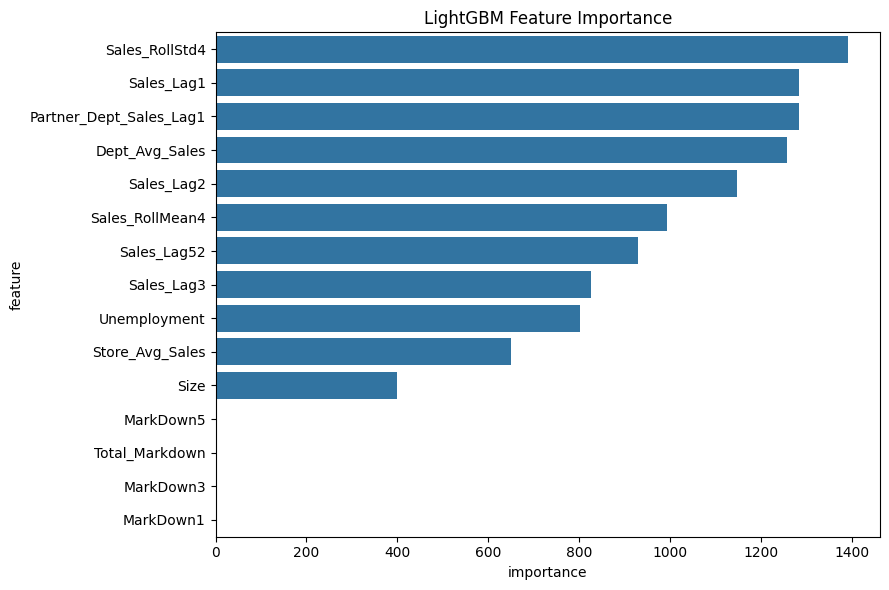

                    feature  importance
5            Sales_RollStd4        1392
0                Sales_Lag1        1283
7   Partner_Dept_Sales_Lag1        1283
6            Dept_Avg_Sales        1256
4                Sales_Lag2        1148
2           Sales_RollMean4         994
1               Sales_Lag52         929
3                Sales_Lag3         825
11             Unemployment         802
8           Store_Avg_Sales         651
9                      Size         399
10                MarkDown5           0
12           Total_Markdown           0
13                MarkDown3           0
14                MarkDown1           0


In [46]:
run = wandb.init(project="walmart-sales-forecasting", group="LightGBM_Training",
                  name="LightGBM_Feature_Importance", job_type="analysis")

importance_df = pd.DataFrame({
    'feature': selected_features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(9, 6))
sns.barplot(x='importance', y='feature', data=importance_df)
plt.title("LightGBM Feature Importance")
plt.tight_layout()
wandb.log({"Feature_Importance": wandb.Image(plt)})
plt.show()
plt.close()

wandb.log({"Feature_Importance_Table": wandb.Table(dataframe=importance_df)})
wandb.finish()

print(importance_df)

## Section 13 — Walk-Forward Cross-Validation (`LightGBM_CV`)
Section 11 only checked ONE fixed split. This retrains fresh models across 4 sliding time folds (leakage-safe maps refit per fold, same fix as Section 10) using the same hyperparameters, and reports the average WMAE -- the real cross-validation the assignment asks for, not a single split mislabeled as one.

In [43]:
def make_walk_forward_folds(data, n_folds=4, val_frac=0.08):
    dates = np.sort(data['Date'].unique())
    n_dates = len(dates)
    val_size = max(1, int(n_dates * val_frac))
    first_cutoff_idx = n_dates - n_folds * val_size
    folds = []
    for i in range(n_folds):
        train_end_idx = first_cutoff_idx + i * val_size
        val_start_idx = train_end_idx
        val_end_idx = train_end_idx + val_size
        folds.append({
            "fold": i,
            "train_start": pd.Timestamp(dates[:train_end_idx].min()),
            "train_end": pd.Timestamp(dates[:train_end_idx].max()),
            "val_start": pd.Timestamp(dates[val_start_idx:val_end_idx].min()),
            "val_end": pd.Timestamp(dates[val_start_idx:val_end_idx].max()),
        })
    return folds

clean_fold_defs = make_walk_forward_folds(df, n_folds=4, val_frac=0.08)
for f in clean_fold_defs:
    print(f"Fold {f['fold']}: train ..{f['train_end'].date()} -> val {f['val_start'].date()}..{f['val_end'].date()}")

prepared_folds = []
for f in clean_fold_defs:
    fold_train = df[(df['Date'] >= f['train_start']) & (df['Date'] <= f['train_end'])].copy()
    fold_val = df[(df['Date'] >= f['val_start']) & (df['Date'] <= f['val_end'])].copy()

    fold_best_partner = compute_best_partner(fold_train)
    fold_dept_avg, fold_store_avg, fold_overall_avg = compute_avg_maps(fold_train)
    partner_lookup = df[['Store', 'Dept', 'Date', 'Sales_Lag1']].rename(
        columns={'Dept': 'Partner_Dept', 'Sales_Lag1': 'Partner_Dept_Sales_Lag1'})

    for split_df in [fold_train, fold_val]:
        split_df['Dept_Avg_Sales'] = split_df['Dept'].map(fold_dept_avg).fillna(fold_overall_avg)
        split_df['Store_Avg_Sales'] = split_df['Store'].map(fold_store_avg).fillna(fold_overall_avg)
        split_df['Partner_Dept'] = split_df['Dept'].map(fold_best_partner)
        split_df.drop(columns=['Partner_Dept_Sales_Lag1'], inplace=True, errors='ignore')

    fold_train = fold_train.merge(partner_lookup, on=['Store', 'Partner_Dept', 'Date'], how='left')
    fold_val = fold_val.merge(partner_lookup, on=['Store', 'Partner_Dept', 'Date'], how='left')
    prepared_folds.append((fold_train, fold_val))

run = wandb.init(project="walmart-sales-forecasting", group="LightGBM_Training",
                  name="LightGBM_CV", job_type="cross-validation")

cv_results = []
for i, (fold_train, fold_val) in enumerate(prepared_folds):
    Xtr, ytr = fold_train[selected_features], fold_train['Weekly_Sales']
    Xva, yva = fold_val[selected_features], fold_val['Weekly_Sales']
    fold_model = lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.05, num_leaves=63,
                                    random_state=42, n_jobs=-1)
    fold_model.fit(Xtr, ytr, eval_set=[(Xva, yva)], eval_metric='l1',
                    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)])
    fold_pred = np.clip(fold_model.predict(Xva), a_min=0, a_max=None)
    fold_wmae = wmae(yva.values, fold_pred, fold_val['IsHoliday'].values)
    cv_results.append({"fold": i, "val_wmae": fold_wmae})
    print(f"Fold {i}: WMAE={fold_wmae:.2f}")

cv_df = pd.DataFrame(cv_results)
mean_wmae, std_wmae = cv_df['val_wmae'].mean(), cv_df['val_wmae'].std()
print(f"\nCross-validated WMAE: {mean_wmae:.2f} +/- {std_wmae:.2f}")

wandb.log({"cv_results": wandb.Table(dataframe=cv_df)})
wandb.log({"cv_mean_wmae": mean_wmae, "cv_std_wmae": std_wmae})
wandb.finish()

Fold 0: train ..2011-12-23 -> val 2011-12-30..2012-03-09
Fold 1: train ..2012-03-09 -> val 2012-03-16..2012-05-25
Fold 2: train ..2012-05-25 -> val 2012-06-01..2012-08-10
Fold 3: train ..2012-08-10 -> val 2012-08-17..2012-10-26


Fold 0: WMAE=2605.14
Fold 1: WMAE=1495.99
Fold 2: WMAE=1282.49
Fold 3: WMAE=1354.82

Cross-validated WMAE: 1684.61 +/- 620.06


cv_mean_wmae,▁
cv_std_wmae,▁
cv_mean_wmae,1684.6088
cv_std_wmae,620.05658


In [44]:
## LightGBM Hyperparameter Search (CV-Averaged, 20 Trials)

import random
random.seed(42)

param_space = {
    "num_leaves":        [31, 47, 63, 95, 127],
    "learning_rate":     [0.01, 0.03, 0.05, 0.08, 0.1],
    "n_estimators":      [500, 1000, 1500, 2000],
    "subsample":         [0.6, 0.8, 1.0],
    "colsample_bytree":  [0.6, 0.8, 1.0],
    "min_child_samples": [10, 20, 30, 50],
    "reg_alpha":         [0.0, 0.1, 0.5, 1.0],
    "reg_lambda":        [1.0, 2.0, 5.0],
}

N_TRIALS = 20
seen = set()
param_grid = []
while len(param_grid) < N_TRIALS:
    combo = {k: random.choice(v) for k, v in param_space.items()}
    key = tuple(sorted(combo.items()))
    if key in seen:
        continue
    seen.add(key)
    param_grid.append(combo)

run = wandb.init(project="walmart-sales-forecasting", group="LightGBM_Training",
                  name="LightGBM_Hyperparameter_Search", job_type="hyperparameter-search")

results = []
for i, params in enumerate(param_grid):
    fold_wmaes = []
    for fold_train, fold_val in prepared_folds:
        Xtr, ytr = fold_train[selected_features], fold_train['Weekly_Sales']
        Xva, yva = fold_val[selected_features], fold_val['Weekly_Sales']

        m = lgb.LGBMRegressor(random_state=42, n_jobs=-1, verbosity=-1, **params)
        m.fit(Xtr, ytr, eval_set=[(Xva, yva)], eval_metric='l1',
              callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)])

        pred = np.clip(m.predict(Xva), a_min=0, a_max=None)
        fold_wmaes.append(wmae(yva.values, pred, fold_val['IsHoliday'].values))

    mean_wmae = float(np.mean(fold_wmaes))
    std_wmae = float(np.std(fold_wmaes))
    results.append({**params, "cv_mean_wmae": mean_wmae, "cv_std_wmae": std_wmae})
    print(f"Trial {i+1}/{N_TRIALS}: cv_mean_wmae={mean_wmae:.2f} (+/-{std_wmae:.2f})")

results_df = pd.DataFrame(results).sort_values("cv_mean_wmae").reset_index(drop=True)
print("\nTop 5 configs:")
print(results_df.head())

best_params = results_df.iloc[0].drop(["cv_mean_wmae", "cv_std_wmae"]).to_dict()
best_params["num_leaves"] = int(best_params["num_leaves"])
best_params["n_estimators"] = int(best_params["n_estimators"])
best_params["min_child_samples"] = int(best_params["min_child_samples"])
print("\nBest params:", best_params)

wandb.log({"search_results": wandb.Table(dataframe=results_df)})
wandb.config.update({"best_params": best_params, "n_trials": N_TRIALS})
wandb.finish()

Trial 1/20: cv_mean_wmae=1652.04 (+/-462.34)
Trial 2/20: cv_mean_wmae=1650.91 (+/-511.88)
Trial 3/20: cv_mean_wmae=1606.02 (+/-394.35)
Trial 4/20: cv_mean_wmae=1611.31 (+/-419.09)
Trial 5/20: cv_mean_wmae=1633.77 (+/-449.65)
Trial 6/20: cv_mean_wmae=1595.04 (+/-380.37)
Trial 7/20: cv_mean_wmae=1643.63 (+/-445.98)
Trial 8/20: cv_mean_wmae=1683.91 (+/-509.25)
Trial 9/20: cv_mean_wmae=1579.63 (+/-359.98)
Trial 10/20: cv_mean_wmae=1681.36 (+/-508.76)
Trial 11/20: cv_mean_wmae=1652.84 (+/-479.36)
Trial 12/20: cv_mean_wmae=1605.78 (+/-428.36)
Trial 13/20: cv_mean_wmae=1613.40 (+/-440.28)
Trial 14/20: cv_mean_wmae=1571.02 (+/-356.24)
Trial 15/20: cv_mean_wmae=1601.13 (+/-425.50)
Trial 16/20: cv_mean_wmae=1583.50 (+/-376.42)
Trial 17/20: cv_mean_wmae=1715.22 (+/-564.63)
Trial 18/20: cv_mean_wmae=1595.72 (+/-397.21)
Trial 19/20: cv_mean_wmae=1641.77 (+/-460.55)
Trial 20/20: cv_mean_wmae=1638.09 (+/-452.51)

Top 5 configs:
   num_leaves  learning_rate  n_estimators  subsample  colsample_bytree  

## Section 14 — Recursive Forecast + Kaggle Submission
`test.csv` asks for predictions ~39 weeks out, not one week ahead. Lag features are only known for the first predicted week, so each subsequent week needs the previous prediction fed back in as if it were real -- this is recursive forecasting, and it's what turned the first submission attempt (7715 WMAE) into a working one (~3477) once fixed.

In [47]:
raw_path = '/content/drive/MyDrive/ML-final/data/raw/'
test_raw = pd.read_csv(raw_path + 'test.csv')
stores_raw = pd.read_csv(raw_path + 'stores.csv')
features_raw = pd.read_csv(raw_path + 'features.csv')

# Retrain on ALL real history using the tree-count validation already found best --
# no reason to withhold real data from the model we actually submit.
final_model = lgb.LGBMRegressor(
    n_estimators=model.best_iteration_,
    learning_rate=0.05,
    num_leaves=63,
    random_state=42,
    n_jobs=-1,
)
final_model.fit(df[selected_features], df['Weekly_Sales'])


def recursive_forecast(model, selected_features, train_full_df, test_raw, stores_df, features_df,
                        dept_avg_map, store_avg_map, best_partner, overall_avg,
                        markdown_cols, holiday_dates, all_holiday_dates):
    test_merged = pd.merge(test_raw, stores_df, on='Store', how='left')
    test_merged = pd.merge(test_merged, features_df, on=['Store', 'Date', 'IsHoliday'], how='left')
    test_merged['Date'] = pd.to_datetime(test_merged['Date'])
    test_merged = test_merged.sort_values(['Store', 'Date']).reset_index(drop=True)
    test_merged['CPI'] = test_merged.groupby('Store')['CPI'].transform(lambda s: s.ffill().bfill())
    test_merged['Unemployment'] = test_merged.groupby('Store')['Unemployment'].transform(lambda s: s.ffill().bfill())

    def days_to_next(date):
        future = all_holiday_dates[all_holiday_dates > date]
        return (future.min() - date).days if len(future) else np.nan

    def days_since_last(date):
        past = all_holiday_dates[all_holiday_dates < date]
        return (date - past.max()).days if len(past) else np.nan

    history = train_full_df[['Store', 'Dept', 'Date', 'Weekly_Sales']].copy()
    all_preds = []
    test_dates = sorted(test_merged['Date'].unique())

    for i, current_date in enumerate(test_dates):
        batch = test_merged[test_merged['Date'] == current_date].copy()

        # Lag features: computed fresh each week, using real history + every prediction made so far
        combined = pd.concat([history, batch[['Store', 'Dept', 'Date']].assign(Weekly_Sales=np.nan)],
                              ignore_index=True, sort=False)
        combined = combined.sort_values(['Store', 'Dept', 'Date']).reset_index(drop=True)
        grp = combined.groupby(['Store', 'Dept'])['Weekly_Sales']
        combined['Sales_Lag1'] = grp.shift(1)
        combined['Sales_Lag2'] = grp.shift(2)
        combined['Sales_Lag3'] = grp.shift(3)
        combined['Sales_Lag52'] = grp.shift(52)
        combined['Sales_RollMean4'] = grp.transform(lambda s: s.shift(1).rolling(4).mean())
        combined['Sales_RollStd4'] = grp.transform(lambda s: s.shift(1).rolling(4).std())

        lag_cols = ['Store', 'Dept', 'Date', 'Sales_Lag1', 'Sales_Lag2', 'Sales_Lag3',
                    'Sales_Lag52', 'Sales_RollMean4', 'Sales_RollStd4']
        batch = pd.merge(batch, combined[lag_cols], on=['Store', 'Dept', 'Date'], how='left')

        # Static per-row info, doesn't need recursion
        batch['Year'] = batch['Date'].dt.year
        batch['Month'] = batch['Date'].dt.month
        batch['Week'] = batch['Date'].dt.isocalendar().week.astype(int)
        batch['Day'] = batch['Date'].dt.day
        batch['Type'] = batch['Type'].map({'A': 3, 'B': 2, 'C': 1})
        batch['IsHoliday'] = batch['IsHoliday'].astype(int)

        batch[markdown_cols] = batch[markdown_cols].fillna(0)
        batch['Total_Markdown'] = batch[markdown_cols].sum(axis=1)
        batch['Has_Markdown'] = (batch['Total_Markdown'] > 0).astype(int)
        batch['Markdown_Count'] = (batch[markdown_cols] > 0).sum(axis=1)

        for col, dts in holiday_dates.items():
            batch[col] = batch['Date'].isin(dts).astype(int)
        batch['Days_To_Next_Holiday'] = batch['Date'].apply(days_to_next)
        batch['Days_Since_Last_Holiday'] = batch['Date'].apply(days_since_last)

        batch['Partner_Dept'] = batch['Dept'].map(best_partner)
        partner_lookup = combined[['Store', 'Dept', 'Date', 'Sales_Lag1']].rename(
            columns={'Dept': 'Partner_Dept', 'Sales_Lag1': 'Partner_Dept_Sales_Lag1'})
        batch = batch.drop(columns=['Partner_Dept_Sales_Lag1'], errors='ignore')
        batch = pd.merge(batch, partner_lookup, on=['Store', 'Partner_Dept', 'Date'], how='left')

        batch['Dept_Avg_Sales'] = batch['Dept'].map(dept_avg_map).fillna(overall_avg)
        batch['Store_Avg_Sales'] = batch['Store'].map(store_avg_map).fillna(overall_avg)

        preds = model.predict(batch[selected_features])
        batch['Weekly_Sales'] = np.clip(preds, a_min=0, a_max=None)

        all_preds.append(batch[['Store', 'Dept', 'Date', 'Weekly_Sales']])
        history = pd.concat([history, batch[['Store', 'Dept', 'Date', 'Weekly_Sales']]], ignore_index=True)

        if (i + 1) % 10 == 0 or i == len(test_dates) - 1:
            print(f"Predicted week {i+1}/{len(test_dates)}: {current_date.date()}")

    return pd.concat(all_preds, ignore_index=True)


result = recursive_forecast(
    final_model, selected_features, df, test_raw, stores_raw, features_raw,
    dept_avg_map, store_avg_map, best_partner, overall_mean_sales,
    markdown_cols, holiday_dates, all_holiday_dates,
)

submission = pd.DataFrame({
    'Id': (result['Store'].astype(str) + '_' + result['Dept'].astype(str) + '_' +
           result['Date'].dt.strftime('%Y-%m-%d')),
    'Weekly_Sales': result['Weekly_Sales']
})

sub_path = '/content/drive/MyDrive/ML-final/submissions/lightgbm_submission_v2.csv'
os.makedirs(os.path.dirname(sub_path), exist_ok=True)
submission.to_csv(sub_path, index=False)

print(submission.head())
print(f"\nSaved: {sub_path}")

Predicted week 10/39: 2013-01-04
Predicted week 20/39: 2013-03-15
Predicted week 30/39: 2013-05-24
Predicted week 39/39: 2013-07-26
               Id  Weekly_Sales
0  1_1_2012-11-02  34690.027968
1  1_2_2012-11-02  45435.117936
2  1_3_2012-11-02   9442.759448
3  1_4_2012-11-02  37730.736224
4  1_5_2012-11-02  28374.846938

Saved: /content/drive/MyDrive/ML-final/submissions/lightgbm_submission_v2.csv


## Section 15 — Full Pipeline + Model Registry
Wraps the already-tested `recursive_fore

In [41]:
class LightGBMFullPipeline:
    """Combines preprocessing, the trained model, and recursive multi-week forecasting
    into one predict() call. Takes RAW test data (unprocessed, same schema as test.csv)
    and returns Weekly_Sales predictions directly -- chaining each week's prediction into
    the next week's lag features, since LightGBM has no built-in sense of time."""

    def __init__(self, model, train_history_full, dept_avg_map, store_avg_map, best_partner,
                 overall_mean_sales, markdown_cols, holiday_dates, all_holiday_dates, selected_features):
        self.model = model
        self.train_history_full = train_history_full[['Store', 'Dept', 'Date', 'Weekly_Sales']].copy()
        self.dept_avg_map = dept_avg_map
        self.store_avg_map = store_avg_map
        self.best_partner = best_partner
        self.overall_mean_sales = overall_mean_sales
        self.markdown_cols = markdown_cols
        self.holiday_dates = holiday_dates
        self.all_holiday_dates = all_holiday_dates
        self.selected_features = selected_features

    def predict(self, raw_df, stores_df, features_df):
        """raw_df: same schema as test.csv (Store, Dept, Date, IsHoliday). Returns a
        DataFrame with Store, Dept, Date, Weekly_Sales (predicted)."""
        return recursive_forecast(
            self.model, self.selected_features, self.train_history_full, raw_df,
            stores_df, features_df, self.dept_avg_map, self.store_avg_map,
            self.best_partner, self.overall_mean_sales, self.markdown_cols,
            self.holiday_dates, self.all_holiday_dates,
        )


run = wandb.init(project="walmart-sales-forecasting", group="LightGBM_Training",
                  name="LightGBM_Save_Pipeline", job_type="pipeline-export")

final_model.booster_.save_model("/content/lightgbm_final_model.txt")

full_pipeline = LightGBMFullPipeline(
    model=final_model,
    train_history_full=df,
    dept_avg_map=dept_avg_map,
    store_avg_map=store_avg_map,
    best_partner=best_partner,
    overall_mean_sales=overall_mean_sales,
    markdown_cols=markdown_cols,
    holiday_dates=holiday_dates,
    all_holiday_dates=all_holiday_dates,
    selected_features=selected_features,
)

import pickle
with open("/content/lightgbm_full_pipeline.pkl", "wb") as f:
    pickle.dump(full_pipeline, f)

model_artifact = wandb.Artifact(name="lightgbm_model", type="model",
                                 description=f"LightGBM model trained on full history, best_iteration={model.best_iteration_}")
model_artifact.add_file("/content/lightgbm_final_model.txt")
wandb.run.log_artifact(model_artifact)

pipeline_artifact = wandb.Artifact(
    name="lightgbm_full_pipeline", type="model",
    description="Complete preprocessing+model+recursive-forecast pipeline, runs directly on raw test.csv"
)
pipeline_artifact.add_file("/content/lightgbm_full_pipeline.pkl")
wandb.run.log_artifact(pipeline_artifact)

# Register to the Model Registry (assignment requirement, not just a generic artifact log).
# If this fails (wandb version/plan differences), link it manually from the wandb UI:
# open this artifact -> "Link to registry".
try:
    run.link_artifact(pipeline_artifact, target_path="model-registry/Walmart-LightGBM-Best-Model")
    print("Linked to Model Registry as 'Walmart-LightGBM-Best-Model'")
except Exception as e:
    print("Could not auto-link to Model Registry -- link it manually in the wandb UI:", e)

wandb.finish()
print("LightGBM model + pipeline saved and registered")

Could not auto-link to Model Registry -- link it manually in the wandb UI: The model registry has been migrated for teams in your organization. You may no longer make changes.


LightGBM model + pipeline saved and registered


## Next Steps
- `LightGBM_Tuning`: sweep `num_leaves`, `learning_rate`, `n_estimators` -- hold out a separate slice from the CV folds if doing a real grid search, so tuning doesn't quietly overfit to the same validation data it's being checked against
- Try switching `Store`/`Dept`/`Type` to native pandas `category` dtype and compare against this numeric-encoded version
- Compare this against your friend's XGBoost WMAE now that both have real CV numbers